<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula08b_kmeans_elbow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:,2:4]
y = data.target

In [2]:
from sklearn.cluster import KMeans

kmeans_k3 = KMeans(n_clusters=3).fit(X)
kmeans_k8 = KMeans(n_clusters=8).fit(X)
print(f"kmeans_k3: {kmeans_k3.inertia_}")
print(f"kmeans_k8: {kmeans_k8.inertia_}")

kmeans_k3: 31.371358974358966
kmeans_k8: 8.311568540043437


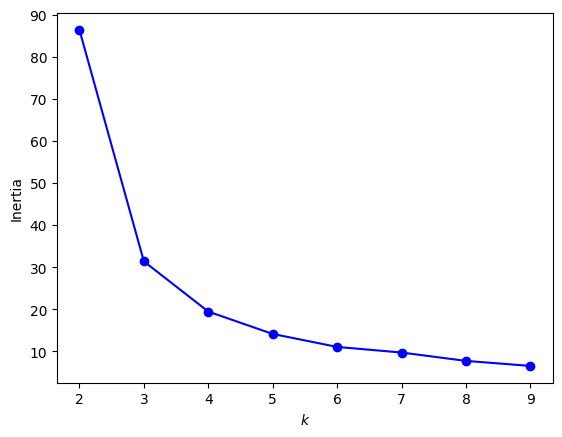

In [4]:
import matplotlib.pyplot as plt

def plot_elbow(X, max_k=10):
  kmeans_per_k = [KMeans(n_clusters=k).fit(X) for k in range(2,max_k)]
  inertias = [model.inertia_ for model in kmeans_per_k]
  plt.plot(range(2,max_k), inertias, "bo-")
  plt.xlabel("$k$")
  plt.ylabel("Inertia")

plot_elbow(X)
plt.show()


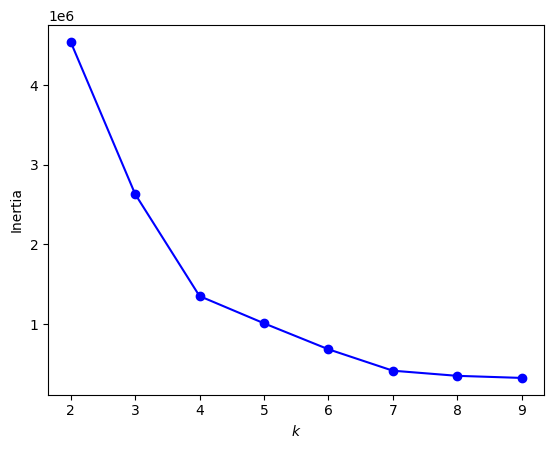

In [5]:
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)
plot_elbow(X)
plt.show()

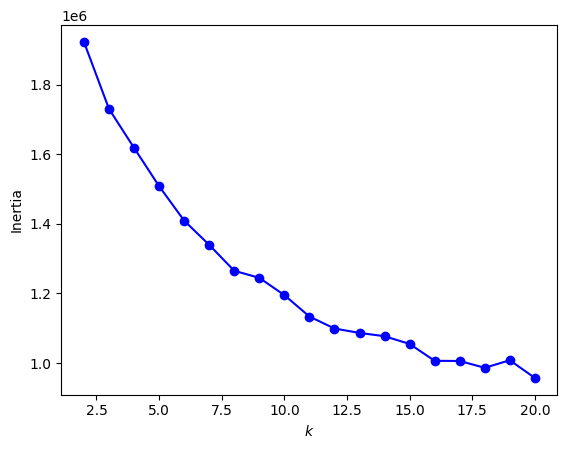

In [15]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
plot_elbow(X, 21)
plt.show()

In [25]:
len(y)

1797

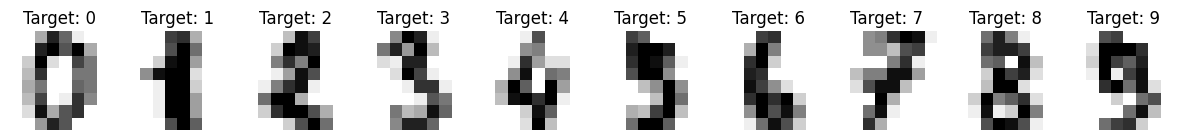

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=10, figsize=(15, 3))
for ax, image, label in zip(axes, X, y):
    ax.set_axis_off()
    ax.imshow(image.reshape((8, 8)), cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Target: {label}')
plt.show()

In [16]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

model = RidgeClassifier()
scores = cross_val_score(model, X, y, cv=5)
print(f"RidgeClassifier: {scores.mean()},\n{scores}")

RidgeClassifier: 0.8881522748375115,
[0.92777778 0.83888889 0.90529248 0.92200557 0.84679666]


In [18]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    KMeans(n_clusters=50),
    RidgeClassifier()
)
scores = cross_val_score(model, X, y, cv=5)
print(f"Pipeline: {scores.mean()},\n{scores}")

Pipeline: 0.9387929433611886,
[0.95833333 0.90833333 0.93871866 0.9637883  0.92479109]


In [19]:
!pip install optuna -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.9 MB/s eta 0:00:00


In [20]:
import optuna

X, y = load_digits(return_X_y=True)

def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 10, 200)
    model = make_pipeline(
        KMeans(n_clusters=n_clusters),
        RidgeClassifier()
    )
    scores = cross_val_score(model, X, y, cv=5)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"Best value: {study.best_value}")
print(f"Best params: {study.best_params}")

[I 2026-05-13 00:05:40,782] A new study created in memory with name: no-name-220851ff-a535-4c09-a904-b679825d2a32
[I 2026-05-13 00:05:43,069] Trial 0 finished with value: 0.9582729805013928 and parameters: {'n_clusters': 135}. Best is trial 0 with value: 0.9582729805013928.
[I 2026-05-13 00:05:43,610] Trial 1 finished with value: 0.9538223460229032 and parameters: {'n_clusters': 95}. Best is trial 0 with value: 0.9582729805013928.
[I 2026-05-13 00:05:44,510] Trial 2 finished with value: 0.958274528009904 and parameters: {'n_clusters': 142}. Best is trial 2 with value: 0.958274528009904.
[I 2026-05-13 00:05:45,333] Trial 3 finished with value: 0.9549365521510369 and parameters: {'n_clusters': 116}. Best is trial 2 with value: 0.958274528009904.
[I 2026-05-13 00:05:45,823] Trial 4 finished with value: 0.9543779015784587 and parameters: {'n_clusters': 97}. Best is trial 2 with value: 0.958274528009904.
[I 2026-05-13 00:05:46,002] Trial 5 finished with value: 0.9054008047044257 and paramet

Best value: 0.962726709996905
Best params: {'n_clusters': 136}


In [21]:
model = make_pipeline(
    KMeans(n_clusters=136),
    RidgeClassifier()
)
scores = cross_val_score(model, X, y, cv=5)
print(f"Pipeline: {scores.mean()},\n{scores}")

Pipeline: 0.9571603218817704,
[0.96944444 0.92777778 0.96657382 0.98607242 0.93593315]


In [29]:
model = make_pipeline(
    KMeans(n_clusters=250),
    RidgeClassifier()
)
scores = cross_val_score(model, X, y, cv=5)
print(f"Pipeline: {scores.mean()},\n{scores}")

Pipeline: 0.965510677808728,
[0.975      0.93333333 0.98328691 0.98607242 0.94986072]
